In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import ast
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [4]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
drive_root = "/content/drive/MyDrive"

pos_matches = []

for root, dirs, files in os.walk(drive_root):
    needed = {
        "scenario23_pos_beam_train.csv",
        "scenario23_pos_beam_val.csv",
        "scenario23_pos_beam_test.csv"
    }
    if needed.issubset(set(files)):
        pos_matches.append(root)

print("Position CSV folder candidates:")
for p in pos_matches:
    print(p)

Position CSV folder candidates:


In [6]:
POS_ROOT = "/content/drive/MyDrive/Pos beam"

pos_train_csv = os.path.join(POS_ROOT, "scenario23_pos_beam_train.csv")
pos_val_csv   = os.path.join(POS_ROOT, "scenario23_pos_beam_val.csv")
pos_test_csv  = os.path.join(POS_ROOT, "scenario23_pos_beam_test.csv")

print(os.path.exists(pos_train_csv), pos_train_csv)
print(os.path.exists(pos_val_csv), pos_val_csv)
print(os.path.exists(pos_test_csv), pos_test_csv)

True /content/drive/MyDrive/Pos beam/scenario23_pos_beam_train.csv
True /content/drive/MyDrive/Pos beam/scenario23_pos_beam_val.csv
True /content/drive/MyDrive/Pos beam/scenario23_pos_beam_test.csv


In [7]:
train_df = pd.read_csv(pos_train_csv)
val_df   = pd.read_csv(pos_val_csv)
test_df  = pd.read_csv(pos_test_csv)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

display(train_df.head())
print(train_df.columns.tolist())

Train: (6832, 3)
Val  : (3416, 3)
Test : (1139, 3)


,index,unit2_pos,unit1_beam
0,3532,"[0.8092883966431671, 0.521083920903955]",17
1,2224,"[0.4816276084988933, 0.29434536152734486]",14
2,9416,"[0.220278556834608, 0.4136596156292844]",17
3,8510,"[0.21412273613497904, 0.4547214157104936]",20
4,6877,"[0.14500641727379412, 0.4097884695072434]",17


['index', 'unit2_pos', 'unit1_beam']


In [8]:
def parse_unit2_pos(pos_value):
    if isinstance(pos_value, str):
        return ast.literal_eval(pos_value)
    return pos_value

def add_position_features(df):
    df = df.copy()

    parsed = df["unit2_pos"].apply(parse_unit2_pos)

    df["pos_x"] = parsed.apply(lambda v: float(v[0]))
    df["pos_y"] = parsed.apply(lambda v: float(v[1]))

    eps = 1e-8

    df["distance"] = np.sqrt(df["pos_x"]**2 + df["pos_y"]**2)
    df["distance2"] = df["distance"] ** 2
    df["distance3"] = df["distance"] ** 3

    df["angle"] = np.arctan2(df["pos_y"], df["pos_x"])
    df["sin_angle"] = np.sin(df["angle"])
    df["cos_angle"] = np.cos(df["angle"])

    df["pos_x2"] = df["pos_x"] ** 2
    df["pos_y2"] = df["pos_y"] ** 2
    df["pos_x3"] = df["pos_x"] ** 3
    df["pos_y3"] = df["pos_y"] ** 3
    df["pos_xy"] = df["pos_x"] * df["pos_y"]

    df["unit_x"] = df["pos_x"] / (df["distance"] + eps)
    df["unit_y"] = df["pos_y"] / (df["distance"] + eps)

    df["sin2_angle"] = np.sin(2 * df["angle"])
    df["cos2_angle"] = np.cos(2 * df["angle"])
    df["sin3_angle"] = np.sin(3 * df["angle"])
    df["cos3_angle"] = np.cos(3 * df["angle"])

    df["dist_sin"] = df["distance"] * df["sin_angle"]
    df["dist_cos"] = df["distance"] * df["cos_angle"]

    return df

train_df_fe = add_position_features(train_df)
val_df_fe   = add_position_features(val_df)
test_df_fe  = add_position_features(test_df)

feature_cols = [
    "pos_x",
    "pos_y",
    "distance",
    "distance2",
    "distance3",
    "angle",
    "sin_angle",
    "cos_angle",
    "pos_x2",
    "pos_y2",
    "pos_x3",
    "pos_y3",
    "pos_xy",
    "unit_x",
    "unit_y",
    "sin2_angle",
    "cos2_angle",
    "sin3_angle",
    "cos3_angle",
    "dist_sin",
    "dist_cos",
]

label_col = "unit1_beam"

print("Number of features:", len(feature_cols))
print("Label column:", label_col)
display(train_df_fe[["index", "unit2_pos", *feature_cols, label_col]].head())

print("Label unique count:", train_df_fe[label_col].nunique())
print("Label min/max:", train_df_fe[label_col].min(), train_df_fe[label_col].max())

Number of features: 21
Label column: unit1_beam


,index,unit2_pos,pos_x,pos_y,distance,distance2,distance3,angle,sin_angle,cos_angle,...,pos_xy,unit_x,unit_y,sin2_angle,cos2_angle,sin3_angle,cos3_angle,dist_sin,dist_cos,unit1_beam
0,3532,"[0.8092883966431671, 0.521083920903955]",0.809288,0.521084,0.962536,0.926476,0.891767,0.572060,0.541365,0.840787,...,0.421707,0.840787,0.541365,0.910347,0.413847,0.989450,-0.144873,0.521084,0.809288,17
1,2224,"[0.4816276084988933, 0.29434536152734486]",0.481628,0.294345,0.564450,0.318604,0.179836,0.548576,0.521472,0.853268,...,0.141765,0.853268,0.521472,0.889912,0.456133,0.997194,-0.074861,0.294345,0.481628,14
2,9416,"[0.220278556834608, 0.4136596156292844]",0.220279,0.413660,0.468654,0.219637,0.102934,1.081479,0.882654,0.470023,...,0.091120,0.470023,0.882654,0.829736,-0.558156,-0.102663,-0.994716,0.413660,0.220279,17
3,8510,"[0.21412273613497904, 0.4547214157104936]",0.214123,0.454721,0.502613,0.252620,0.126970,1.130709,0.904714,0.426019,...,0.097366,0.426019,0.904714,0.770851,-0.637016,-0.247920,-0.968780,0.454721,0.214123,20
4,6877,"[0.14500641727379412, 0.4097884695072434]",0.145006,0.409788,0.434688,0.188953,0.082136,1.230690,0.942719,0.333588,...,0.059422,0.333588,0.942719,0.628959,-0.777439,-0.523094,-0.852275,0.409788,0.145006,17


Label unique count: 29
Label min/max: 2 30


In [9]:
all_labels = sorted(train_df_fe[label_col].astype(int).unique())

label_to_id = {label: i for i, label in enumerate(all_labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

num_classes = len(all_labels)

print("num_classes:", num_classes)
print("label_to_id:", label_to_id)
print("id_to_label:", id_to_label)

num_classes: 29
label_to_id: {np.int64(2): 0, np.int64(3): 1, np.int64(4): 2, np.int64(5): 3, np.int64(6): 4, np.int64(7): 5, np.int64(8): 6, np.int64(9): 7, np.int64(10): 8, np.int64(11): 9, np.int64(12): 10, np.int64(13): 11, np.int64(14): 12, np.int64(15): 13, np.int64(16): 14, np.int64(17): 15, np.int64(18): 16, np.int64(19): 17, np.int64(20): 18, np.int64(21): 19, np.int64(22): 20, np.int64(23): 21, np.int64(24): 22, np.int64(25): 23, np.int64(26): 24, np.int64(27): 25, np.int64(28): 26, np.int64(29): 27, np.int64(30): 28}
id_to_label: {0: np.int64(2), 1: np.int64(3), 2: np.int64(4), 3: np.int64(5), 4: np.int64(6), 5: np.int64(7), 6: np.int64(8), 7: np.int64(9), 8: np.int64(10), 9: np.int64(11), 10: np.int64(12), 11: np.int64(13), 12: np.int64(14), 13: np.int64(15), 14: np.int64(16), 15: np.int64(17), 16: np.int64(18), 17: np.int64(19), 18: np.int64(20), 19: np.int64(21), 20: np.int64(22), 21: np.int64(23), 22: np.int64(24), 23: np.int64(25), 24: np.int64(26), 25: np.int64(27), 26

In [10]:
train_mean = train_df_fe[feature_cols].astype(float).mean()
train_std  = train_df_fe[feature_cols].astype(float).std().replace(0, 1)

print("Train mean:")
display(train_mean)

print("Train std:")
display(train_std)

Train mean:


,0
pos_x,0.343933
pos_y,0.396131
distance,0.540083
distance2,0.311916
distance3,0.193269
angle,0.870551
sin_angle,0.744473
cos_angle,0.625777
pos_x2,0.141736
pos_y2,0.170180


Train std:


,0
pos_x,0.153132
pos_y,0.115162
distance,0.142230
distance2,0.177328
distance3,0.181966
angle,0.236080
sin_angle,0.161494
cos_angle,0.167600
pos_x2,0.137104
pos_y2,0.098119


dataset class 

In [11]:
class PositionBeamDataset(Dataset):
    def __init__(self, df, feature_cols, label_col, mean, std, label_to_id):
        self.df = df.reset_index(drop=True).copy()
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.mean = mean
        self.std = std
        self.label_to_id = label_to_id

        x = self.df[self.feature_cols].astype(float)
        x = (x - self.mean) / self.std

        y_raw = self.df[self.label_col].astype(int).values
        y = [self.label_to_id[int(v)] for v in y_raw]

        self.x = torch.tensor(x.values, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [12]:
batch_size = 64

dataset_train = PositionBeamDataset(train_df_fe, feature_cols, label_col, train_mean, train_std, label_to_id)
dataset_val   = PositionBeamDataset(val_df_fe, feature_cols, label_col, train_mean, train_std, label_to_id)
dataset_test  = PositionBeamDataset(test_df_fe, feature_cols, label_col, train_mean, train_std, label_to_id)

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

print("Train size:", len(dataset_train))
print("Val size  :", len(dataset_val))
print("Test size :", len(dataset_test))

Train size: 6832
Val size  : 3416
Test size : 1139


sanity check 

In [13]:
x_batch, y_batch = next(iter(train_loader))

input_dim = x_batch.shape[1]

print("x_batch:", x_batch.shape)
print("y_batch:", y_batch.shape)
print("input_dim:", input_dim)
print("num_classes:", num_classes)

print("First x:", x_batch[:3])
print("First mapped labels:", y_batch[:10])
print("First original labels:", [id_to_label[int(i)] for i in y_batch[:10]])

assert input_dim == len(feature_cols)
assert y_batch.min().item() >= 0
assert y_batch.max().item() < num_classes

print(" Data pipeline ready.")

x_batch: torch.Size([64, 21])
y_batch: torch.Size([64])
input_dim: 21
num_classes: 29
First x: tensor([[ 0.6498,  0.5952,  0.7187,  0.5675,  0.3941, -0.2616, -0.1302,  0.3854,
          0.4004,  0.4662,  0.1678,  0.2887,  0.8351,  0.3854, -0.1302,  0.8648,
          0.2681,  0.6081, -0.1658,  0.5952,  0.6498],
        [-0.8635, -1.5201, -1.6452, -1.2306, -0.9045, -0.2690, -0.1376,  0.3929,
         -0.7069, -1.2363, -0.5570, -0.8822, -1.1001,  0.3929, -0.1376,  0.8659,
          0.2762,  0.6164, -0.1575, -1.5201, -0.8635],
        [-0.5376, -2.0916, -1.6584, -1.2371, -0.9074, -1.4188, -1.4496,  1.3973,
         -0.5346, -1.4887, -0.4785, -0.9746, -1.1752,  1.3973, -1.4496, -0.0185,
          1.5058,  1.3398,  1.5702, -2.0916, -0.5376]])
First mapped labels: tensor([15,  2,  0, 24, 13, 18, 13, 28,  9, 15])
First original labels: [np.int64(17), np.int64(4), np.int64(2), np.int64(26), np.int64(15), np.int64(20), np.int64(15), np.int64(30), np.int64(11), np.int64(17)]
 Data pipeline ready.

position mlp model 

In [14]:
class PositionMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(512, 256, 128, 64), dropout=0.10):
        super().__init__()

        h1, h2, h3, h4 = hidden_dims

        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(h2, h3),
            nn.BatchNorm1d(h3),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(h3, h4),
            nn.BatchNorm1d(h4),
            nn.GELU(),

            nn.Linear(h4, num_classes)
        )

    def forward(self, x):
        return self.net(x)

top k evaluation 

In [15]:
def evaluate_topk(model, loader, device, ks=(1, 2, 3, 5)):
    model.eval()

    total = 0
    correct = {k: 0 for k in ks}

    with torch.no_grad():
        for x, labels in loader:
            x = x.to(device)
            labels = labels.to(device)

            outputs = model(x)

            max_k = max(ks)
            _, pred = torch.topk(outputs, k=max_k, dim=1)
            pred = pred.t()

            total += labels.size(0)

            for k in ks:
                correct[k] += pred[:k].eq(labels.view(1, -1)).sum().item()

    return {f"top{k}": 100.0 * correct[k] / total for k in ks}

trainer 

In [16]:
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=120,
    lr=2e-4,
    weight_decay=1e-6,
    milestones=(70, 100),
    save_path="/content/drive/MyDrive/best_position_mlp_tracking.pth"
):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=list(milestones),
        gamma=0.1
    )

    best_top1 = -1
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_train = 0

        for x, labels in train_loader:
            x = x.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            bs = labels.size(0)
            running_loss += loss.item() * bs
            total_train += bs

        scheduler.step()

        train_loss = running_loss / total_train
        val_metrics = evaluate_topk(model, val_loader, device, ks=(1, 2, 3, 5))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            **val_metrics
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Top1: {val_metrics['top1']:.2f} | "
            f"Top2: {val_metrics['top2']:.2f} | "
            f"Top3: {val_metrics['top3']:.2f} | "
            f"Top5: {val_metrics['top5']:.2f}"
        )

        if val_metrics["top1"] > best_top1:
            best_top1 = val_metrics["top1"]
            torch.save(copy.deepcopy(model.state_dict()), save_path)
            print("Saved best model")

    return pd.DataFrame(history)

train position mlp 

In [17]:
set_seed(42)

model = PositionMLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=(512, 256, 128, 64),
    dropout=0.10
).to(device)

save_path = "/content/drive/MyDrive/best_position_mlp_tracking.pth"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=120,
    lr=2e-4,
    weight_decay=1e-6,
    milestones=(70, 100),
    save_path=save_path
)

Epoch 001 | Loss: 2.7303 | Val Top1: 48.77 | Top2: 68.00 | Top3: 77.75 | Top5: 86.45
Saved best model
Epoch 002 | Loss: 2.1074 | Val Top1: 50.53 | Top2: 72.25 | Top3: 83.02 | Top5: 92.56
Saved best model
Epoch 003 | Loss: 1.8073 | Val Top1: 51.49 | Top2: 74.00 | Top3: 85.28 | Top5: 93.79
Saved best model
Epoch 004 | Loss: 1.6225 | Val Top1: 55.09 | Top2: 77.08 | Top3: 87.18 | Top5: 94.09
Saved best model
Epoch 005 | Loss: 1.5295 | Val Top1: 54.45 | Top2: 77.49 | Top3: 87.56 | Top5: 94.85
Epoch 006 | Loss: 1.4526 | Val Top1: 54.45 | Top2: 77.20 | Top3: 87.68 | Top5: 94.99
Epoch 007 | Loss: 1.4200 | Val Top1: 56.59 | Top2: 78.78 | Top3: 88.00 | Top5: 95.35
Saved best model
Epoch 008 | Loss: 1.3785 | Val Top1: 55.42 | Top2: 78.45 | Top3: 88.38 | Top5: 95.02
Epoch 009 | Loss: 1.3724 | Val Top1: 55.91 | Top2: 78.19 | Top3: 87.70 | Top5: 95.20
Epoch 010 | Loss: 1.3377 | Val Top1: 57.20 | Top2: 78.92 | Top3: 88.11 | Top5: 95.43
Saved best model
Epoch 011 | Loss: 1.3275 | Val Top1: 58.40 | Top

In [18]:
model_eval = PositionMLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=(512, 256, 128, 64),
    dropout=0.10
).to(device)

model_eval.load_state_dict(torch.load(save_path, map_location=device))

test_metrics = evaluate_topk(model_eval, test_loader, device, ks=(1, 2, 3, 5))

print("Position MLP Test Metrics:")
print(test_metrics)

Position MLP Test Metrics:
{'top1': 60.7550482879719, 'top2': 82.61633011413521, 'top3': 92.2739244951712, 'top5': 98.33187006145742}


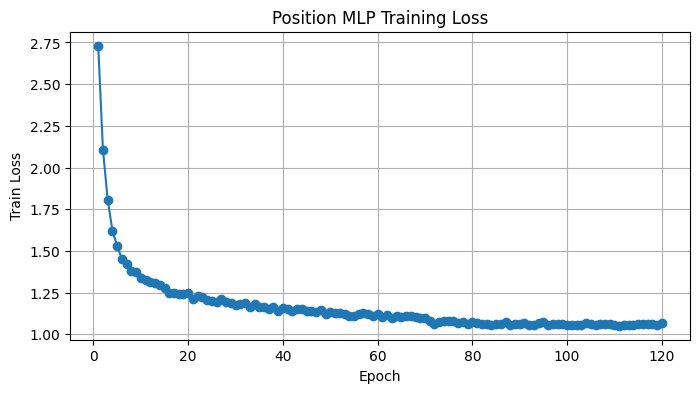

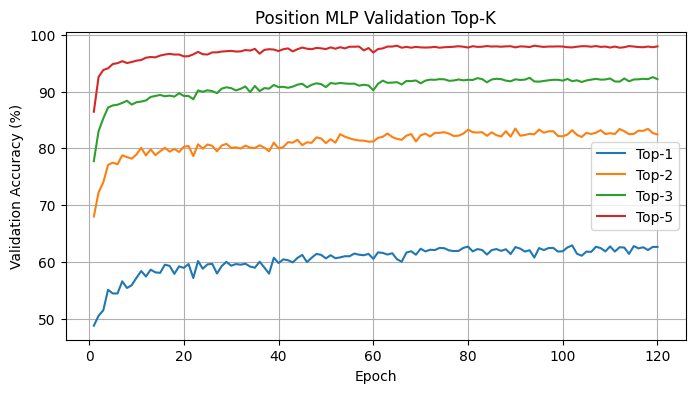

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], history["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Position MLP Training Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], history["top1"], label="Top-1")
plt.plot(history["epoch"], history["top2"], label="Top-2")
plt.plot(history["epoch"], history["top3"], label="Top-3")
plt.plot(history["epoch"], history["top5"], label="Top-5")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Position MLP Validation Top-K")
plt.legend()
plt.grid(True)
plt.show()

sequence tracking 

stage 2 lstm 

train_df_fe, val_df_fe, test_df_fe
feature_cols
label_col
label_to_id, id_to_label
num_classes
train_mean, train_std
device

In [41]:
def build_position_sequences_relaxed(
    df,
    feature_cols,
    label_col,
    label_to_id,
    mean,
    std,
    seq_len=4
):
    df = df.sort_values("index").reset_index(drop=True).copy()

    x_raw = df[feature_cols].astype(float)
    x_norm = (x_raw - mean) / std
    x_values = x_norm.values.astype(np.float32)

    y_raw = df[label_col].astype(int).values

    X_seq = []
    y_seq = []

    # input: rows i-3, i-2, i-1, i
    # target: row i+1
    for i in range(seq_len - 1, len(df) - 1):
        X_seq.append(x_values[i - seq_len + 1 : i + 1])
        y_seq.append(label_to_id[int(y_raw[i + 1])])

    X_seq = torch.tensor(np.array(X_seq), dtype=torch.float32)
    y_seq = torch.tensor(np.array(y_seq), dtype=torch.long)

    return X_seq, y_seq


SEQ_LEN = 4

X_train_seq, y_train_seq = build_position_sequences_relaxed(
    train_df_fe, feature_cols, label_col, label_to_id, train_mean, train_std, seq_len=SEQ_LEN
)

X_val_seq, y_val_seq = build_position_sequences_relaxed(
    val_df_fe, feature_cols, label_col, label_to_id, train_mean, train_std, seq_len=SEQ_LEN
)

X_test_seq, y_test_seq = build_position_sequences_relaxed(
    test_df_fe, feature_cols, label_col, label_to_id, train_mean, train_std, seq_len=SEQ_LEN
)

print("X_train_seq:", X_train_seq.shape, "y_train_seq:", y_train_seq.shape)
print("X_val_seq  :", X_val_seq.shape, "y_val_seq  :", y_val_seq.shape)
print("X_test_seq :", X_test_seq.shape, "y_test_seq :", y_test_seq.shape)

X_train_seq: torch.Size([6828, 4, 21]) y_train_seq: torch.Size([6828])
X_val_seq  : torch.Size([3412, 4, 21]) y_val_seq  : torch.Size([3412])
X_test_seq : torch.Size([1135, 4, 21]) y_test_seq : torch.Size([1135])


In [42]:
class PositionSequenceDataset(Dataset):
    def __init__(self, X_seq, y_seq):
        self.X_seq = X_seq
        self.y_seq = y_seq

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.y_seq[idx]


seq_batch_size = 64

train_seq_dataset = PositionSequenceDataset(X_train_seq, y_train_seq)
val_seq_dataset   = PositionSequenceDataset(X_val_seq, y_val_seq)
test_seq_dataset  = PositionSequenceDataset(X_test_seq, y_test_seq)

print("Train seq dataset:", len(train_seq_dataset))
print("Val seq dataset  :", len(val_seq_dataset))
print("Test seq dataset :", len(test_seq_dataset))

assert len(train_seq_dataset) > 0, "Train sequence dataset is empty"
assert len(val_seq_dataset) > 0, "Val sequence dataset is empty"
assert len(test_seq_dataset) > 0, "Test sequence dataset is empty"

train_seq_loader = DataLoader(train_seq_dataset, batch_size=seq_batch_size, shuffle=True)
val_seq_loader   = DataLoader(val_seq_dataset, batch_size=seq_batch_size, shuffle=False)
test_seq_loader  = DataLoader(test_seq_dataset, batch_size=seq_batch_size, shuffle=False)

x_seq_batch, y_seq_batch = next(iter(train_seq_loader))

print("x_seq_batch:", x_seq_batch.shape)
print("y_seq_batch:", y_seq_batch.shape)

seq_input_dim = x_seq_batch.shape[-1]

print("seq_len:", x_seq_batch.shape[1])
print("seq_input_dim:", seq_input_dim)
print("num_classes:", num_classes)

Train seq dataset: 6828
Val seq dataset  : 3412
Test seq dataset : 1135
x_seq_batch: torch.Size([64, 4, 21])
y_seq_batch: torch.Size([64])
seq_len: 4
seq_input_dim: 21
num_classes: 29


In [43]:
class PositionLSTMTracker(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
        hidden_dim=256,
        num_layers=3,
        dropout=0.20
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [B, 4, input_dim]
        x = self.input_proj(x)
        out, (h, c) = self.lstm(x)

        # final time step representation
        last = out[:, -1, :]

        logits = self.classifier(last)
        return logits

top k evaluation 

In [44]:
def evaluate_topk_seq(model, loader, device, ks=(1, 2, 3, 5)):
    model.eval()

    total = 0
    correct = {k: 0 for k in ks}

    with torch.no_grad():
        for x, labels in loader:
            x = x.to(device)
            labels = labels.to(device)

            outputs = model(x)

            max_k = max(ks)
            _, pred = torch.topk(outputs, k=max_k, dim=1)
            pred = pred.t()

            total += labels.size(0)

            for k in ks:
                correct[k] += pred[:k].eq(labels.view(1, -1)).sum().item()

    if total == 0:
        raise ValueError("Loader is empty. No samples were available for evaluation.")

    return {f"top{k}": 100.0 * correct[k] / total for k in ks}

In [45]:
def train_sequence_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=120,
    lr=2e-4,
    weight_decay=1e-6,
    milestones=(70, 100),
    save_path="/content/drive/MyDrive/best_position_lstm_tracker.pth"
):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=list(milestones),
        gamma=0.1
    )

    best_top1 = -1
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_train = 0

        for x, labels in train_loader:
            x = x.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            bs = labels.size(0)
            running_loss += loss.item() * bs
            total_train += bs

        scheduler.step()

        train_loss = running_loss / total_train
        val_metrics = evaluate_topk_seq(model, val_loader, device, ks=(1, 2, 3, 5))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            **val_metrics
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Top1: {val_metrics['top1']:.2f} | "
            f"Top2: {val_metrics['top2']:.2f} | "
            f"Top3: {val_metrics['top3']:.2f} | "
            f"Top5: {val_metrics['top5']:.2f}"
        )

        if val_metrics["top1"] > best_top1:
            best_top1 = val_metrics["top1"]
            torch.save(copy.deepcopy(model.state_dict()), save_path)
            print("Saved best sequence model")

    return pd.DataFrame(history)

In [46]:
set_seed(42)

seq_model = PositionLSTMTracker(
    input_dim=seq_input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    num_layers=3,
    dropout=0.20
).to(device)

seq_save_path = "/content/drive/MyDrive/best_position_lstm_tracker.pth"

history_seq = train_sequence_model(
    model=seq_model,
    train_loader=train_seq_loader,
    val_loader=val_seq_loader,
    device=device,
    epochs=120,
    lr=2e-4,
    weight_decay=1e-6,
    milestones=(70, 100),
    save_path=seq_save_path
)

Epoch 001 | Loss: 2.3637 | Val Top1: 38.83 | Top2: 58.97 | Top3: 70.16 | Top5: 81.92
Saved best sequence model
Epoch 002 | Loss: 1.6874 | Val Top1: 46.10 | Top2: 65.97 | Top3: 76.41 | Top5: 86.49
Saved best sequence model
Epoch 003 | Loss: 1.4508 | Val Top1: 49.59 | Top2: 71.98 | Top3: 80.89 | Top5: 88.80
Saved best sequence model
Epoch 004 | Loss: 1.3268 | Val Top1: 51.06 | Top2: 73.12 | Top3: 83.85 | Top5: 91.03
Saved best sequence model
Epoch 005 | Loss: 1.2756 | Val Top1: 53.81 | Top2: 75.12 | Top3: 84.35 | Top5: 91.74
Saved best sequence model
Epoch 006 | Loss: 1.2183 | Val Top1: 54.10 | Top2: 76.00 | Top3: 85.35 | Top5: 92.56
Saved best sequence model
Epoch 007 | Loss: 1.2020 | Val Top1: 54.57 | Top2: 76.55 | Top3: 85.20 | Top5: 92.32
Saved best sequence model
Epoch 008 | Loss: 1.1730 | Val Top1: 56.27 | Top2: 76.70 | Top3: 85.61 | Top5: 93.32
Saved best sequence model
Epoch 009 | Loss: 1.1623 | Val Top1: 58.03 | Top2: 77.37 | Top3: 86.17 | Top5: 93.49
Saved best sequence model
E

In [47]:
seq_model_eval = PositionLSTMTracker(
    input_dim=seq_input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    num_layers=3,
    dropout=0.20
).to(device)

seq_model_eval.load_state_dict(torch.load(seq_save_path, map_location=device))

seq_test_metrics = evaluate_topk_seq(
    seq_model_eval,
    test_seq_loader,
    device,
    ks=(1, 2, 3, 5)
)

print("Position LSTM Tracking Test Metrics:")
print(seq_test_metrics)

Position LSTM Tracking Test Metrics:
{'top1': 44.31718061674009, 'top2': 62.731277533039645, 'top3': 71.80616740088105, 'top5': 80.79295154185021}


clear overfitting 

so try to using small model 

lightweight lstm  

In [48]:
class SmallPositionLSTMTracker(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
        hidden_dim=64,
        num_layers=1,
        dropout=0.35
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        logits = self.classifier(last)
        return logits

added  early stoping 

In [50]:
def train_sequence_model_earlystop(
    model,
    train_loader,
    val_loader,
    device,
    epochs=80,
    lr=1e-4,
    weight_decay=1e-3,
    patience=12,
    save_path="/content/drive/MyDrive/best_small_position_lstm_tracker.pth"
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_total = 0
        train_correct = 0

        for x, labels in train_loader:
            x = x.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            bs = labels.size(0)
            train_loss_sum += loss.item() * bs
            train_total += bs
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()

        train_loss = train_loss_sum / train_total
        train_acc = 100.0 * train_correct / train_total

        model.eval()
        val_loss_sum = 0.0
        val_total = 0

        with torch.no_grad():
            for x, labels in val_loader:
                x = x.to(device)
                labels = labels.to(device)

                outputs = model(x)
                loss = criterion(outputs, labels)

                bs = labels.size(0)
                val_loss_sum += loss.item() * bs
                val_total += bs

        val_loss = val_loss_sum / val_total
        val_metrics = evaluate_topk_seq(model, val_loader, device, ks=(1, 2, 3, 5))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            **val_metrics
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Top1: {val_metrics['top1']:.2f} | "
            f"Top3: {val_metrics['top3']:.2f} | "
            f"Top5: {val_metrics['top5']:.2f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(copy.deepcopy(model.state_dict()), save_path)
            print("Saved best small LSTM")
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    return pd.DataFrame(history)

Train only small Lstm

In [51]:
set_seed(42)

small_seq_model = SmallPositionLSTMTracker(
    input_dim=seq_input_dim,
    num_classes=num_classes,
    hidden_dim=64,
    num_layers=1,
    dropout=0.35
).to(device)

small_seq_save_path = "/content/drive/MyDrive/best_small_position_lstm_tracker.pth"

history_small_seq = train_sequence_model_earlystop(
    model=small_seq_model,
    train_loader=train_seq_loader,
    val_loader=val_seq_loader,
    device=device,
    epochs=80,
    lr=1e-4,
    weight_decay=1e-3,
    patience=12,
    save_path=small_seq_save_path
)

Epoch 001 | Train Loss: 3.0418 | Train Acc: 20.33 | Val Loss: 2.6870 | Val Top1: 30.54 | Top3: 62.16 | Top5: 73.89
Saved best small LSTM
Epoch 002 | Train Loss: 2.5841 | Train Acc: 33.11 | Val Loss: 2.3808 | Val Top1: 36.66 | Top3: 68.99 | Top5: 78.81
Saved best small LSTM
Epoch 003 | Train Loss: 2.3353 | Train Acc: 37.86 | Val Loss: 2.2076 | Val Top1: 43.46 | Top3: 71.92 | Top5: 81.95
Saved best small LSTM
Epoch 004 | Train Loss: 2.1679 | Train Acc: 40.51 | Val Loss: 2.0949 | Val Top1: 43.26 | Top3: 72.80 | Top5: 83.03
Saved best small LSTM
Epoch 005 | Train Loss: 2.0617 | Train Acc: 42.55 | Val Loss: 2.0162 | Val Top1: 43.38 | Top3: 73.27 | Top5: 83.91
Saved best small LSTM
Epoch 006 | Train Loss: 1.9686 | Train Acc: 44.80 | Val Loss: 1.9618 | Val Top1: 44.34 | Top3: 73.65 | Top5: 85.02
Saved best small LSTM
Epoch 007 | Train Loss: 1.9111 | Train Acc: 44.39 | Val Loss: 1.9207 | Val Top1: 45.34 | Top3: 75.03 | Top5: 85.79
Saved best small LSTM
Epoch 008 | Train Loss: 1.8641 | Train Ac

In [52]:
small_seq_model_eval = SmallPositionLSTMTracker(
    input_dim=seq_input_dim,
    num_classes=num_classes,
    hidden_dim=64,
    num_layers=1,
    dropout=0.35
).to(device)

small_seq_model_eval.load_state_dict(torch.load(small_seq_save_path, map_location=device))

small_seq_test_metrics = evaluate_topk_seq(
    small_seq_model_eval,
    test_seq_loader,
    device,
    ks=(1, 2, 3, 5)
)

print("Small Position LSTM Tracking Test Metrics:")
print(small_seq_test_metrics)

Small Position LSTM Tracking Test Metrics:
{'top1': 42.819383259911895, 'top2': 61.93832599118943, 'top3': 71.89427312775331, 'top5': 81.3215859030837}


do it from first 

In [53]:
import os

drive_root = "/content/drive/MyDrive"

matches = []

for root, dirs, files in os.walk(drive_root):
    for f in files:
        if f in [
            "scenario23_img_beam.csv",
            "scenario23_pos_beam.csv",
            "scenario23.csv"
        ]:
            matches.append(os.path.join(root, f))

print("Found full CSV files:")
for m in matches:
    print(m)

Found full CSV files:
/content/drive/MyDrive/Image beam/scenario23_img_beam.csv
/content/drive/MyDrive/Pos beam/scenario23_pos_beam.csv


In [54]:
FULL_CSV_PATH = "/content/drive/MyDrive/Pos beam/scenario23_pos_beam.csv"

full_df = pd.read_csv(FULL_CSV_PATH)

print(full_df.shape)
display(full_df.head())
print(full_df.columns.tolist())

(11387, 3)


,index,unit2_pos,unit1_beam
0,1,"[0.3195560203421424, 0.4874879026449761]",22
1,2,"[0.3176783761879752, 0.48679662657070005]",22
2,3,"[0.31603840851137044, 0.48610535045712955]",22
3,4,"[0.31458858201343814, 0.4854140743828535]",22
4,5,"[0.3123544231513711, 0.48444628784743143]",20


['index', 'unit2_pos', 'unit1_beam']


In [55]:
full_df = full_df.sort_values("index").reset_index(drop=True)

print(full_df[["index", "unit2_pos", "unit1_beam"]].head())
print(full_df[["index", "unit2_pos", "unit1_beam"]].tail())

print("Total samples:", len(full_df))
print("Index min/max:", full_df["index"].min(), full_df["index"].max())

   index                                   unit2_pos  unit1_beam
0      1    [0.3195560203421424, 0.4874879026449761]          22
1      2   [0.3176783761879752, 0.48679662657070005]          22
2      3  [0.31603840851137044, 0.48610535045712955]          22
3      4   [0.31458858201343814, 0.4854140743828535]          22
4      5   [0.3123544231513711, 0.48444628784743143]          20
       index                                  unit2_pos  unit1_beam
11382  11383  [0.33025146171424064, 0.4216784183738069]          20
11383  11384   [0.3300137852366781, 0.4216784183738069]          19
11384  11385   [0.3298236440580057, 0.4216784183738069]          19
11385  11386   [0.3293482911028806, 0.4218166735847326]          19
11386  11387  [0.32922945287254335, 0.4219549287956584]          19
Total samples: 11387
Index min/max: 1 11387


continuity check

In [56]:
idx = full_df["index"].astype(int).values

diffs = np.diff(idx)

print("Unique index differences:", np.unique(diffs, return_counts=True))
print("Number of continuous +1 transitions:", np.sum(diffs == 1))
print("Number of broken transitions:", np.sum(diffs != 1))

Unique index differences: (array([1]), array([11386]))
Number of continuous +1 transitions: 11386
Number of broken transitions: 0


In [58]:
import ast
import numpy as np

def parse_unit2_pos(pos_value):
    if isinstance(pos_value, str):
        return ast.literal_eval(pos_value)
    return pos_value

def add_position_features(df):
    df = df.copy()

    parsed = df["unit2_pos"].apply(parse_unit2_pos)

    df["pos_x"] = parsed.apply(lambda v: float(v[0]))
    df["pos_y"] = parsed.apply(lambda v: float(v[1]))

    eps = 1e-8

    df["distance"] = np.sqrt(df["pos_x"]**2 + df["pos_y"]**2)
    df["distance2"] = df["distance"] ** 2
    df["distance3"] = df["distance"] ** 3

    df["angle"] = np.arctan2(df["pos_y"], df["pos_x"])
    df["sin_angle"] = np.sin(df["angle"])
    df["cos_angle"] = np.cos(df["angle"])

    df["pos_x2"] = df["pos_x"] ** 2
    df["pos_y2"] = df["pos_y"] ** 2
    df["pos_x3"] = df["pos_x"] ** 3
    df["pos_y3"] = df["pos_y"] ** 3

    df["pos_xy"] = df["pos_x"] * df["pos_y"]

    df["unit_x"] = df["pos_x"] / (df["distance"] + eps)
    df["unit_y"] = df["pos_y"] / (df["distance"] + eps)

    df["sin2_angle"] = np.sin(2 * df["angle"])
    df["cos2_angle"] = np.cos(2 * df["angle"])
    df["sin3_angle"] = np.sin(3 * df["angle"])
    df["cos3_angle"] = np.cos(3 * df["angle"])

    df["dist_sin"] = df["distance"] * df["sin_angle"]
    df["dist_cos"] = df["distance"] * df["cos_angle"]

    return df


full_df_fe = add_position_features(full_df)

feature_cols = [
    "pos_x", "pos_y",
    "distance", "distance2", "distance3",
    "angle", "sin_angle", "cos_angle",
    "pos_x2", "pos_y2", "pos_x3", "pos_y3",
    "pos_xy",
    "unit_x", "unit_y",
    "sin2_angle", "cos2_angle",
    "sin3_angle", "cos3_angle",
    "dist_sin", "dist_cos"
]

label_col = "unit1_beam"

print("Feature count:", len(feature_cols))
print("Label unique:", full_df_fe[label_col].nunique())
print("Label min/max:", full_df_fe[label_col].min(), full_df_fe[label_col].max())

Feature count: 21
Label unique: 29
Label min/max: 2 30
